In [2]:
import sys

sys.path.append('./numba_code')
from numba_code.solver_accelerated import (
    calculate_band_structure_numba,
    calculate_nonhermitian_bands_numba
)

sys.path.append('./original_code')
from original_code.params import get_params
from original_code.config import get_config
from original_code.plot import plot_results, plot_nonhermitian_bands


params = get_params()
DELTA_VALUES = params['DELTA_VALUES']
PHI1_VALUES = params['PHI1_VALUES']
PHI2_VALUES = params['PHI2_VALUES']
ALPHA_VALUES = params['ALPHA_VALUES']
BETA_VALUES = params['BETA_VALUES']
EPSILON0_VALUES = params['EPSILON0_VALUES']
EPSILON0_TILDE_VALUES = params['EPSILON0_TILDE_VALUES']

config = get_config()
L_TOTAL = config["L_TOTAL"]
L_A = config["L_A"]
L_F = config["L_F"]
OMEGA_MAX = config["OMEGA_MAX"]
OMEGA_STEPS = config["OMEGA_STEPS"]
TOLERANCE = config["TOLERANCE"] 

In [ ]:
#from itertools import product
from tqdm.contrib.itertools import product

all_param_combinations = product(
    DELTA_VALUES, PHI1_VALUES, PHI2_VALUES, ALPHA_VALUES,
    BETA_VALUES, EPSILON0_VALUES, EPSILON0_TILDE_VALUES
)

In [ ]:
vals = next(all_param_combinations)

In [ ]:
vals

In [ ]:
vals2 = next(all_param_combinations)
vals2

# Testing Hermitian Calculation

### Numba optimized code

In [ ]:
k_points, omega_points = calculate_band_structure_numba(
    *vals, L_TOTAL, L_A, L_F,
    OMEGA_MAX, OMEGA_STEPS, TOLERANCE
)
k_points = k_points.tolist()
omega_points = omega_points.tolist()
plot_results(k_points, omega_points)

# Testing Non-Hermitian Calculation

In [ ]:
omega_vals, q_vals = calculate_nonhermitian_bands_numba(
    *vals2, L_TOTAL, L_A, L_F,
    OMEGA_MAX, OMEGA_STEPS, TOLERANCE
)
plot_nonhermitian_bands(omega_vals, q_vals)

# Generate Dataset
---

In [ ]:
#from itertools import product
from tqdm.contrib.itertools import product

all_param_combinations = product(
    DELTA_VALUES, PHI1_VALUES, PHI2_VALUES, ALPHA_VALUES,
    BETA_VALUES, EPSILON0_VALUES, EPSILON0_TILDE_VALUES
)

In [ ]:
import matplotlib.pyplot as plt
import os

# Generating data
i = 0
for param_combination in all_param_combinations:
    i += 1
    k_points, omega_points = calculate_band_structure_numba(
        *param_combination, *list(config.values())
    )
    path = os.path.join('./data', str(i) + 'png')
    plot_results(k_points, omega_points, path)

In [ ]:
import os
import numpy as np

# Generating data
i = 0
for param_combination in all_param_combinations:

    path = os.path.join('./data', str(i))
    
    if isinstance(param_combination[-2], complex):
        print(i)
        print(*param_combination)
        omega_vals, q_vals = calculate_nonhermitian_bands_numba(
            *param_combination, *list(config.values())
        )
        plot_nonhermitian_bands(omega_vals, q_vals, path)
        np.savez_compressed(file=f"./numpy_arrays/{i}", omega_values=omega_vals, q_values=q_vals)
    else:
        k_points, omega_points = calculate_band_structure_numba(
            *param_combination, *list(config.values()), save=True
        )
        plot_results(k_points, omega_points, path)
        np.savez_compressed(file=f"./numpy_arrays/{i}", k_values=k_points, omega_values=omega_points)
    i += 1

# Generate individual samples
---

In [3]:
omega_vals, q_vals = calculate_nonhermitian_bands_numba(
    DELTA=5.0, PHI1=5.0, PHI2=1.0, ALPHA=0.25,
    BETA=0.75, EPSILON0=13.0 + 5.0j, EPSILON0_TILDE=3.0,
    L_TOTAL=L_TOTAL, L_A=L_A, L_F=L_F, OMEGA_MAX=0.6, OMEGA_STEPS=60_000,
    TOLERANCE=5e-4   
)

Calculating non-Hermitian band structure...
Warming up Numba JIT compilation...
Compilation complete. Starting parallel computation...
Using 16 CPU cores
Found 6513 band points



In [ ]:
import numpy as np
# Each q value maps to at least 5 imaginary eigenvalues
np.min(np.unique_counts(q_vals)[1])

np.int64(5)

In [17]:
import numpy as np

def get_first_five_bands(all_omega, all_q):
    unique_ks = np.unique(all_q)
    k_filtered = []
    omega_filtered = []

    for k in unique_ks:
        # 1. Find all eigenvalues associated with this specific k
        indices = np.where(all_q == k)[0]
        omegas_at_k = all_omega[indices]
        
        # 2. Sort by Real part (as suggested by the paper )
        # This aligns the eigenvalues into continuous bands 1 through 5
        sorted_omegas = omegas_at_k[np.argsort(omegas_at_k.real)]
        
        # 3. Take the first 5 (the lowest frequency bands [cite: 60])
        top_five = sorted_omegas[:5]
        
        for val in top_five:
            k_filtered.append(k)
            omega_filtered.append(val)
            
    return np.array(k_filtered), np.array(omega_filtered)

# Usage:
k_clean, omega_clean = get_first_five_bands(omega_vals, q_vals)

In [21]:
k_clean[0:len(k_clean):5]
omega_clean[0:len(omega_clean):5]

array([0.11199011-1.85512002e-02j, 0.11199431-1.85565060e-02j,
       0.11199658-1.85613209e-02j, 0.1119969 -1.85656437e-02j,
       0.1119953 -1.85694729e-02j, 0.11199175-1.85728075e-02j,
       0.11198627-1.85756463e-02j, 0.11197885-1.85779886e-02j,
       0.1119695 -1.85798333e-02j, 0.11195821-1.85811799e-02j,
       0.11194499-1.85820278e-02j, 0.11192983-1.85823765e-02j,
       0.11191274-1.85822257e-02j, 0.11189372-1.85815752e-02j,
       0.11187277-1.85804249e-02j, 0.11184989-1.85787748e-02j,
       0.11182509-1.85766251e-02j, 0.11179837-1.85739761e-02j,
       0.11176972-1.85708281e-02j, 0.11173916-1.85671816e-02j,
       0.11170668-1.85630374e-02j, 0.1116723 -1.85583960e-02j,
       0.111636  -1.85532585e-02j, 0.1115978 -1.85476257e-02j,
       0.1115577 -1.85414989e-02j, 0.1115157 -1.85348791e-02j,
       0.11147181-1.85277677e-02j, 0.11142603-1.85201662e-02j,
       0.11137837-1.85120761e-02j, 0.11132883-1.85034991e-02j,
       0.11127741-1.84944368e-02j, 0.11122413-1.8484891

In [31]:
omega_real = [omega.real for omega in omega_clean]
omega_imag = [omega.imag for omega in omega_clean]

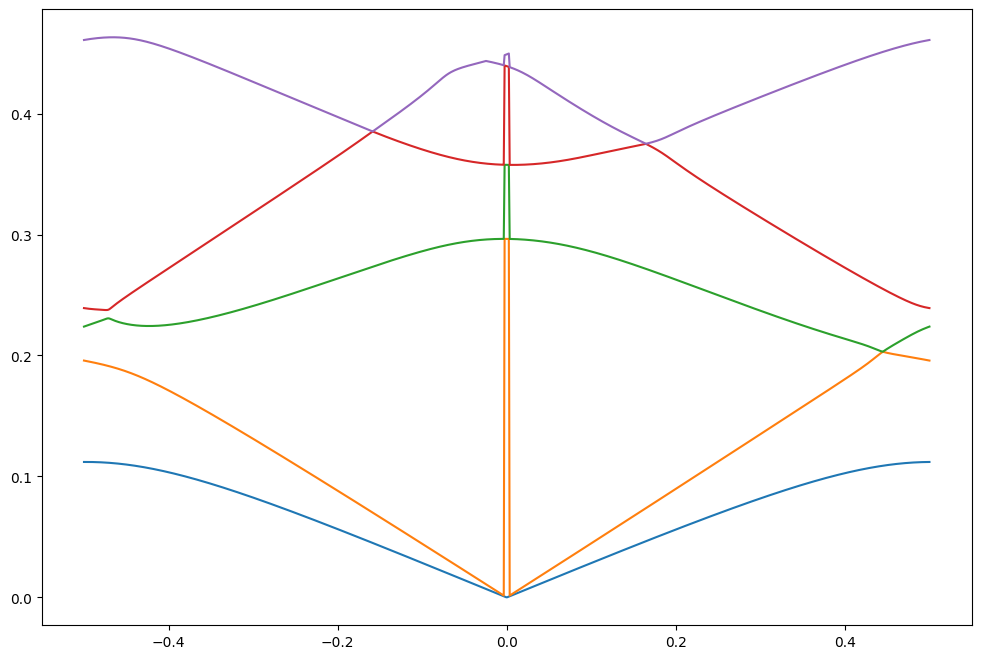

In [ ]:
import matplotlib.pyplot as plt

# Plot real parts
plt.figure(figsize=(12, 8))
plt.plot(k_clean[0:len(k_clean):5], omega_real[0:len(omega_real):5])
plt.plot(k_clean[1:len(k_clean):5], omega_real[1:len(omega_real):5])
plt.plot(k_clean[2:len(k_clean):5], omega_real[2:len(omega_real):5])
plt.plot(k_clean[3:len(k_clean):5], omega_real[3:len(omega_real):5])
plt.plot(k_clean[4:len(k_clean):5], omega_real[4:len(omega_real):5])
plt.show()

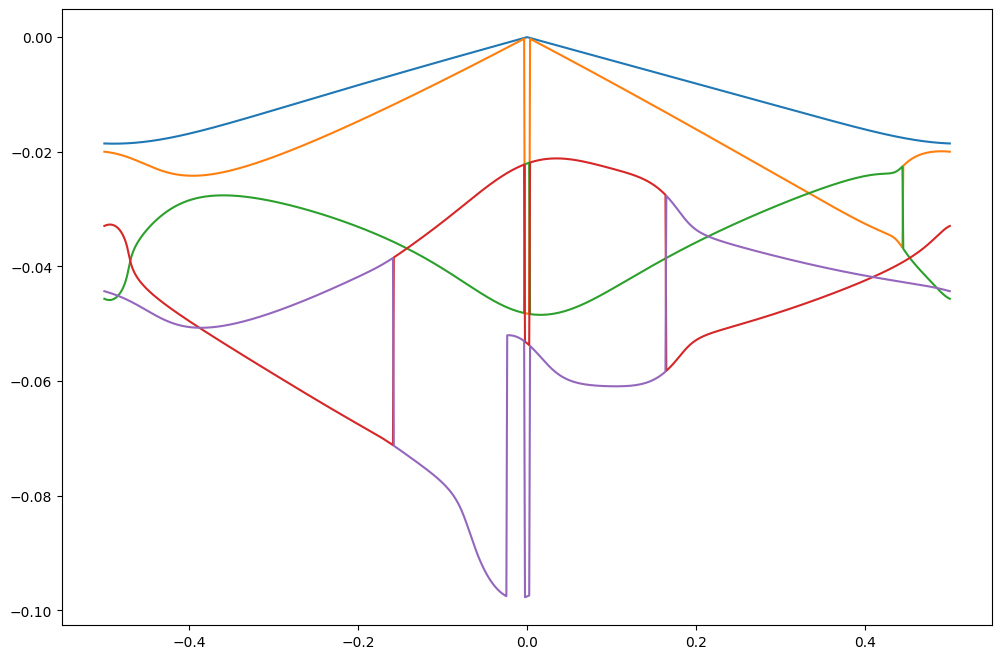

In [32]:
import matplotlib.pyplot as plt

# Plot real parts
plt.figure(figsize=(12, 8))
plt.plot(k_clean[0:len(k_clean):5], omega_imag[0:len(omega_imag):5])
plt.plot(k_clean[1:len(k_clean):5], omega_imag[1:len(omega_imag):5])
plt.plot(k_clean[2:len(k_clean):5], omega_imag[2:len(omega_imag):5])
plt.plot(k_clean[3:len(k_clean):5], omega_imag[3:len(omega_imag):5])
plt.plot(k_clean[4:len(k_clean):5], omega_imag[4:len(omega_imag):5])
plt.show()

In [34]:
def track_bands(k_unique, omega_grid):
    """
    omega_grid should be (Nq, 5) 
    Reorders each row to match the 'closest' value from the previous row.
    """
    tracked_omega = np.zeros_like(omega_grid)
    # Initialize with the first k-point
    tracked_omega[0, :] = omega_grid[0, :] 

    for i in range(1, len(k_unique)):
        prev_omegas = tracked_omega[i-1, :]
        current_omegas = omega_grid[i, :]
        
        # Create a cost matrix (distances between all pairs)
        # Using complex distance: |w1 - w2|
        distances = np.abs(current_omegas[:, np.newaxis] - prev_omegas)
        
        # Match each current eigenvalue to the closest previous one
        # For 5 bands, a simple greedy approach or scipy.optimize.linear_sum_assignment works
        from scipy.optimize import linear_sum_assignment
        row_ind, col_ind = linear_sum_assignment(distances)
        
        # Reorder current omegas based on the optimal matching
        tracked_omega[i, col_ind] = current_omegas[row_ind]
        
    return tracked_omega

In [37]:
omega_clean

array([0.11199011-0.0185512j , 0.19580716-0.01998517j,
       0.22388556-0.0456545j , ..., 0.22388556-0.0456545j ,
       0.23917778-0.03293919j, 0.46078643-0.04432527j], shape=(5000,))

In [41]:
k_unique = np.unique(q_vals)
omega_grid = omega_clean.reshape(1000, 5)

In [51]:
sorted_omega = track_bands(k_unique, omega_grid)
sorted_real_omega = sorted_omega.real
sorted_imag_omega = sorted_omega.imag

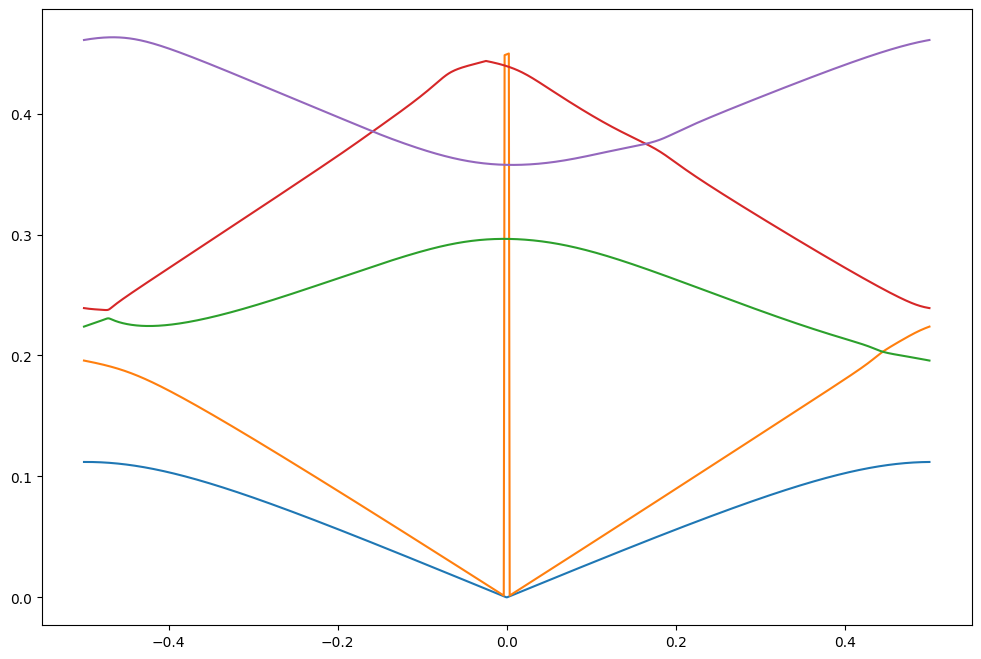

In [53]:
plt.figure(figsize=(12, 8))
plt.plot(k_unique, sorted_real_omega[:,0])
plt.plot(k_unique, sorted_real_omega[:,1])
plt.plot(k_unique, sorted_real_omega[:,2])
plt.plot(k_unique, sorted_real_omega[:,3])
plt.plot(k_unique, sorted_real_omega[:,4])
plt.show()

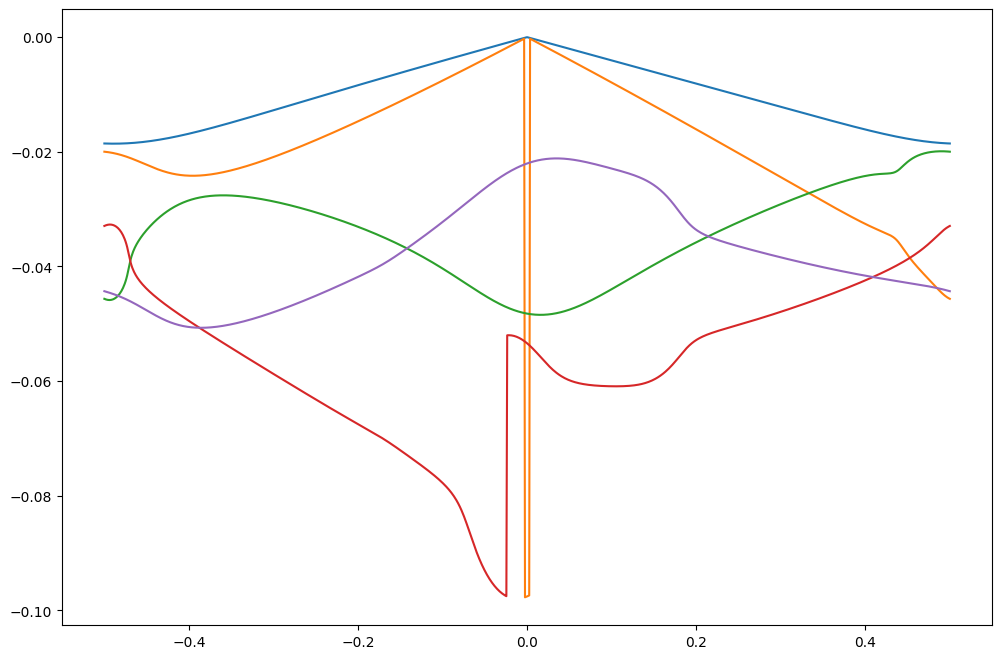

In [54]:
plt.figure(figsize=(12, 8))
plt.plot(k_unique, sorted_imag_omega[:,0])
plt.plot(k_unique, sorted_imag_omega[:,1])
plt.plot(k_unique, sorted_imag_omega[:,2])
plt.plot(k_unique, sorted_imag_omega[:,3])
plt.plot(k_unique, sorted_imag_omega[:,4])
plt.show()

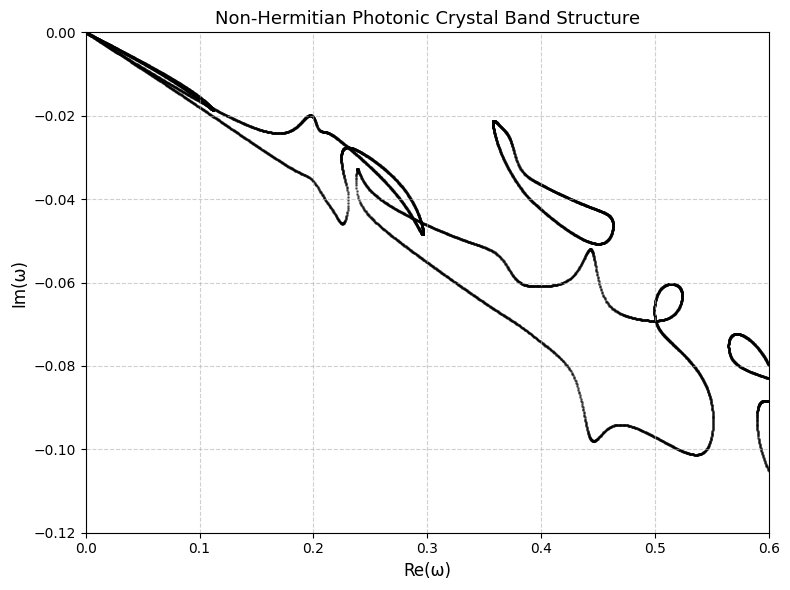

In [33]:
plot_nonhermitian_bands(omega_vals, q_vals)